### Performance so far
- test data accuracy -> 88%  [Unseen Data]
- training data accuracy -> 98%
### Over-Fitting :
- when the gap is significantly high in accuracy of test and training data
### How to reduce the gap ??

### Solutions :  
1. Adding MORE DATA
2. Reducing the COMPLEXITY OF NN Architecture  [multiple layers and many more]
3. REGULARIZATION [There are two types L1 and L2]
- In Regularization we add a penality term in loss fun so we try to reduce both loss and penality and in DL we use L2
4. DROP-OUTS : During training, we randomly turnoff the few neurons and we do this in hidden layers
5. DATA AUGMENTATION : we modify or images like tilting, flipping -> which gives different varities, But it works better with CNN
6. BATCH NORMALIZATION [side outcome : regularization]
7. EARLY STOPPING : if we notice no improvement after certain epochs then we stop the training
### For now we are going to use Regularization, Dropouts and Batch Normalization
[others are not applicable right now, and some we will see later]

In [107]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [108]:
# Set random seeds for reproducibility
torch.manual_seed(42)

In [109]:
# Check for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [110]:
with open('fashion-mnist_train.csv', 'r') as f:
    for i, line in enumerate(f, start=1):
        if 940 <= i <= 950:
            print(i, len(line.split(',')))

940 785
941 785
942 785
943 785
944 785
945 785
946 785
947 785
948 785
949 785
950 785


In [111]:
# df = pd.read_csv('fashion-mnist_train.csv')
# df.head()
# ParserError                               Traceback (most recent call last)
# /tmp/ipykernel_2186/671941430.py in <cell line: 0>()
# ----> 1 df = pd.read_csv('fashion-mnist_train.csv')
#       2 df.head()

# 3 frames
# /usr/local/lib/python3.13/dist-packages/pandas/io/parsers/c_parser_wrapper.py in read(self, nrows)
#     232         try:
#     233             if self.low_memory:
# --> 234                 chunks = self._reader.read_low_memory(nrows)
#     235                 # destructive to chunks
#     236                 data = _concatenate_chunks(chunks)

# parsers.pyx in pandas._libs.parsers.TextReader.read_low_memory()

# parsers.pyx in pandas._libs.parsers.TextReader._read_rows()

# parsers.pyx in pandas._libs.parsers.TextReader._tokenize_rows()

# parsers.pyx in pandas._libs.parsers.TextReader._check_tokenize_status()

# parsers.pyx in pandas._libs.parsers.raise_parser_error()

# ParserError: Error tokenizing data. C error: Expected 785 fields in line 946, saw 1309


In [112]:
# on_bad_lines='skip' using this code to avoid the above error

In [113]:
# if required
# df = pd.read_csv('fashion-mnist_train.csv', on_bad_lines='skip')
# df.head()

In [114]:
df = pd.read_csv('fashion-mnist_train.csv')
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [115]:
df.shape

(60000, 785)

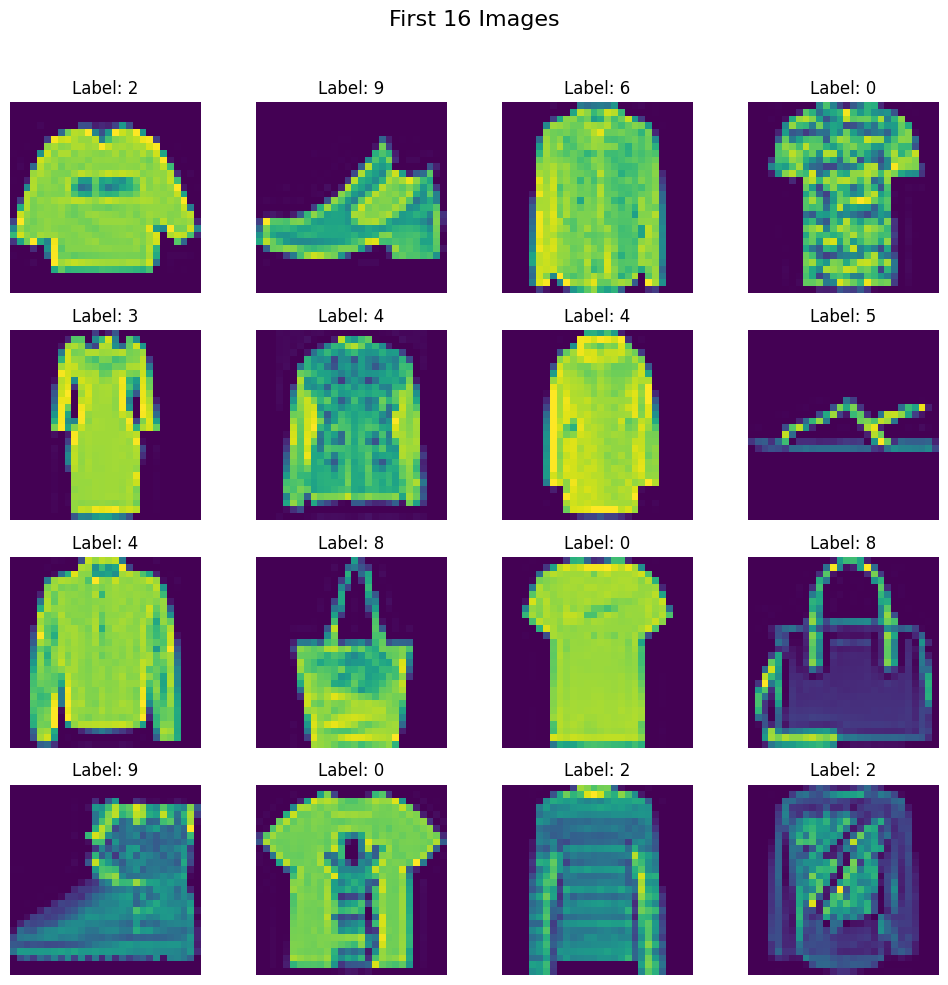

In [116]:
# Create a 4x4 grid of images
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle("First 16 Images", fontsize=16)

# Plot the first 16 images from the dataset
for i, ax in enumerate(axes.flat):
    img = df.iloc[i, 1:].values.reshape(28, 28)  # Reshape to 28x28
    ax.imshow(img)  # Display in grayscale
    ax.axis('off')  # Remove axis for a cleaner look
    ax.set_title(f"Label: {df.iloc[i, 0]}")  # Show the label

plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust layout to fit the title
plt.show()


In [117]:
# train test split

X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values

In [118]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [119]:
X_train = X_train/255.0
X_test = X_test/255.0

In [120]:
class CustomDataset(Dataset):

  def __init__(self, features, labels):

    # Convert to PyTorch tensors
    self.features = torch.tensor(features, dtype=torch.float32)
    self.labels = torch.tensor(labels, dtype=torch.long)

  def __len__(self):
    return len(self.features)

  def __getitem__(self, index):
    return self.features[index], self.labels[index]

In [121]:
train_dataset = CustomDataset(X_train, y_train)

In [122]:
test_dataset = CustomDataset(X_test, y_test)

In [123]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, pin_memory=True)

In [124]:
len(train_loader)

1500

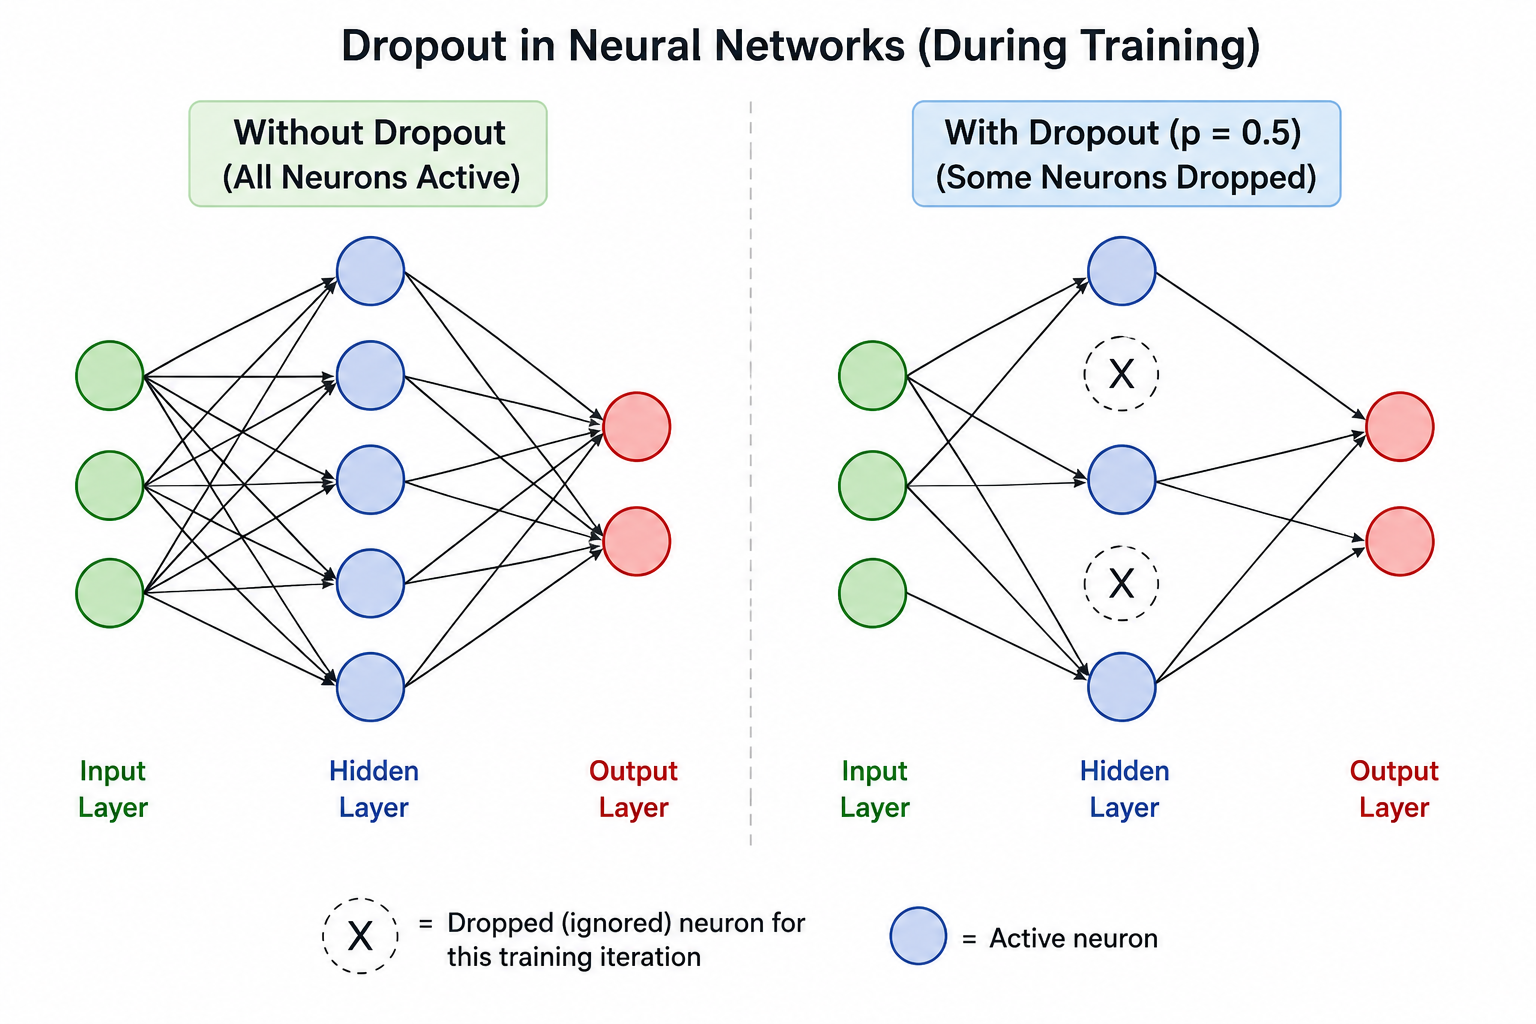

### What is Dropout?

**Dropout is a regularization technique used in neural networks to reduce overfitting.** During training, Dropout randomly deactivates some neurons in a layer for a particular forward pass. These neurons are temporarily ignored, meaning their output becomes zero and they don't participate in that training step. In the next iteration, a different set of neurons may be dropped. This forces the network to learn using multiple neurons rather than becoming overly dependent on specific neurons, which helps the model generalize better to unseen data.

### Important points

* **Dropout is mainly used to prevent overfitting.**
* `p` represents the **probability of dropping a neuron**.

  * `p = 0.2` → 20% neurons are dropped.
  * `p = 0.5` → 50% neurons are dropped.
* Dropout is applied **randomly during training**.
* The dropped neuron produces **0 output** for that particular forward pass.
* A different set of neurons can be dropped in the next iteration.
* Dropout is **active with `model.train()`**.
* Dropout is **disabled with `model.eval()`**; all neurons are used during inference.
* In PyTorch:

```python
nn.Dropout(p=0.3)
```

means **30% dropout probability**.

* Dropout doesn't permanently remove neurons or weights—the neurons are only **temporarily ignored during training**.


Batch Normalization — Short Notes

In simple terms:
During training, the weights of one layer keep changing. Because of this, the outputs of that layer can also change in scale. The next layer then receives inputs with different distributions and has to continuously adapt to those changes, which can make training harder. Batch Normalization normalizes these activations to keep their scale more stable, making optimization easier and training more stable.

Key Points
Problem: Weights change → layer outputs change → next layer sees changing input distributions.

Without BatchNorm:

Layer 1 → [2, 3, 4, 5] → Layer 2
Layer 1 → [20, 30, 40, 50] → Layer 2
Layer 1 → [200, 300, 400, 500] → Layer 2

Layer 2 keeps adapting to different scales.

With BatchNorm:

Layer 1 → [200, 300, 400, 500]
                ↓
           BatchNorm
                ↓
          normalized values
                ↓
             Layer 2
BatchNorm calculates mean and variance for the mini-batch.
It normalizes the activations to roughly mean = 0 and variance = 1.

It then uses learnable parameters γ (gamma) and β (beta) to scale and shift the normalized values:

y=γ
x
^
+β
Main benefit: makes the inputs received by the next layer more stable.
This can lead to faster and more stable training.
BatchNorm does not stop activations from changing; it mainly controls their scale/distribution.

Where to Apply Batch Normalization

Typical structure:

Input
  ↓
Linear / Conv Layer
  ↓
Batch Normalization
  ↓
Activation (ReLU)
  ↓
Next Layer

For a fully connected network:

Linear → BatchNorm → ReLU → Linear → BatchNorm → ReLU

For CNNs:

Conv → BatchNorm → ReLU → Conv → BatchNorm → ReLU

Rule of thumb: BatchNorm is generally applied after the Linear/Convolution layer and before the activation function.

Regularization — Short Notes

In simple terms:
Regularization is a technique used to prevent a neural network from overfitting. When a model becomes too complex, it may learn the training data extremely well, including noise and unnecessary patterns, but perform poorly on unseen data. Regularization adds a constraint or penalty that encourages the model to learn simpler, more general patterns.

Key Points
Problem: Model performs very well on training data but poorly on unseen/test data → Overfitting.
Goal: Improve generalization to new data.
Regularization discourages the model from becoming unnecessarily complex.
Common regularization techniques:
L1 Regularization → encourages some weights to become exactly 0.
L2 Regularization → discourages very large weights.
Dropout → randomly disables some neurons during training.
Early Stopping → stops training when validation performance starts getting worse.
Data Augmentation → creates variations of training examples.
For L2 regularization, the loss becomes:
Total Loss=Original Loss+λ∑w
2

where λ (lambda) controls how strongly we penalize large weights.
- applied over weights
- a pentalty term added with original loss
- we will apply L2 regularization through optimizer with the help of Weight Decay

In [130]:
class MyNN(nn.Module):

  def __init__(self, num_features):

    super().__init__()
    self.model = nn.Sequential(
        # below are the hidden layers

        nn.Linear(num_features, 128),
        # SO before activation we will apply the BATCH NORM
        nn.BatchNorm1d(128),
        nn.ReLU(),
        # SO after activation we will apply the DROPOUTS
        nn.Dropout(p=0.3),        #---- I dropout------#
        nn.Linear(128, 64),
        nn.BatchNorm1d(64),
        nn.ReLU(),
        nn.Dropout(p=0.3),        #---- II dropout------#
        nn.Linear(64, 10)

    )

  def forward(self, x):

    return self.model(x)


In [131]:
learning_rate = 0.1
epochs = 100

In [132]:
# instatiate the model
model = MyNN(X_train.shape[1])
model = model.to(device)
# loss function
criterion = nn.CrossEntropyLoss()
# optimizer
# here we apply the L2 regularization
optimizer = optim.SGD(model.parameters(), lr=learning_rate, weight_decay=1e-4)
# 1e-4 means 10^-4  [weight_decay or lambda [regularization cofficient]]

In [133]:
# training loop

for epoch in range(epochs):

  total_epoch_loss = 0

  for batch_features, batch_labels in train_loader:

    # move data to gpu
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

    # forward pass
    outputs = model(batch_features)

    # calculate loss
    loss = criterion(outputs, batch_labels)

    # back pass
    optimizer.zero_grad()
    loss.backward()

    # update grads
    optimizer.step()

    total_epoch_loss = total_epoch_loss + loss.item()

  avg_loss = total_epoch_loss/len(train_loader)
  print(f'Epoch: {epoch + 1} , Loss: {avg_loss}')


Epoch: 1 , Loss: 0.6230495528181393
Epoch: 2 , Loss: 0.49329839963714284
Epoch: 3 , Loss: 0.4617016841272513
Epoch: 4 , Loss: 0.4356808280249437
Epoch: 5 , Loss: 0.4164183708131313
Epoch: 6 , Loss: 0.4012117492258549
Epoch: 7 , Loss: 0.3950883801927169
Epoch: 8 , Loss: 0.38604395957291127
Epoch: 9 , Loss: 0.37789171273509664
Epoch: 10 , Loss: 0.36907646983861925
Epoch: 11 , Loss: 0.36267625301579637
Epoch: 12 , Loss: 0.3557465855081876
Epoch: 13 , Loss: 0.35663062280913194
Epoch: 14 , Loss: 0.3485886078973611
Epoch: 15 , Loss: 0.3472538322856029
Epoch: 16 , Loss: 0.34083686911066374
Epoch: 17 , Loss: 0.3418472380712628
Epoch: 18 , Loss: 0.3319587858219942
Epoch: 19 , Loss: 0.3292938082565864
Epoch: 20 , Loss: 0.33054758307586113
Epoch: 21 , Loss: 0.32810996471345427
Epoch: 22 , Loss: 0.325763969356815
Epoch: 23 , Loss: 0.3213634921759367
Epoch: 24 , Loss: 0.3170148978779713
Epoch: 25 , Loss: 0.31619742536048095
Epoch: 26 , Loss: 0.31545461183041335
Epoch: 27 , Loss: 0.31595885238051413

In [134]:
model.eval()

MyNN(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [135]:
# evaluation code [For Test Data]
total = 0
correct = 0

with torch.no_grad():

  for batch_features, batch_labels in test_loader:

    # move data to gpu
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

    outputs = model(batch_features)

    _, predicted = torch.max(outputs, 1)

    total = total + batch_labels.shape[0]

    correct = correct + (predicted == batch_labels).sum().item()

print(correct/total)

0.8898333333333334


In [136]:
# evaluation code[For Training Data]
total = 0
correct = 0

with torch.no_grad():

  for batch_features, batch_labels in train_loader:

    # move data to gpu
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

    outputs = model(batch_features)

    _, predicted = torch.max(outputs, 1)

    total = total + batch_labels.shape[0]

    correct = correct + (predicted == batch_labels).sum().item()

print(correct/total)

0.9408125


In [141]:
# NOW DIFFERENCE IS 5% TRAINING DATA(94%) AND TEST DATA(88%)
# OVER-FITTING HAVE REDUCED AT SOME LEVEL [REDUCED BY 5%]
print((0.9408125 - 0.8898333333333334)*100, "%")

5.097916666666668 %
